In [1]:
import numpy as np
from numpy.typing import NDArray
import pandas as pd

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBRegressor
import lightgbm as lgb

import os
import sys
root_path="/home/iaw/DATA2/AAReact/src"
sys.path.append(root_path)
from util.RegressMetrics import r2_score, mse_score, mae_score, rmse_score
from util.train_tools import build_model, search_parms, split_data, load_data, eval_dataset_split
from tool.analysis import draw_pred_result

import seaborn as sns
from matplotlib import pyplot as plt

from typing import List, Tuple
from rich.table import Table
from rich import print as rp
from rich.progress import track
import shap
import pickle

from joblib import dump, load
from copy import deepcopy

In [22]:
seed = 1
test_size = 0.2

# 模型初始训练数据
prefix1 = "/home/iaw/DATA2/AAReact/DataSet/AtropicAcid_424/data_for_train/soap_xtb_3"
data_x, data_y, x_label, data_class = load_data(
    "{}_data_x.npy".format(prefix1), 
    "{}_data_y.npy".format(prefix1), 
    "{}_x_label.pkl".format(prefix1), 
    "{}_data_class.pkl".format(prefix1)
)

# 数据集外验证集
prefix2 = "/home/iaw/DATA2/AAReact/DataSet/AtropicAcid_20_Iter1/data_for_train/soap_xtb_3"
data_x_new, data_y_new, x_label_new, data_class_new = load_data(
    "{}_data_x.npy".format(prefix2), 
    "{}_data_y.npy".format(prefix2), 
    "{}_x_label.pkl".format(prefix2), 
    "{}_data_class.pkl".format(prefix2)
)

# load best model
best_model = load("/home/iaw/DATA2/AAReact/train/output/pt/xgb_model_seed_1_split_0-2_hyper2_soap_xtb.pkl")

# 预测
extra_pred = best_model.predict(data_x_new)


In [23]:
r2_score(extra_pred, data_y_new)

np.float64(0.6038119106290603)

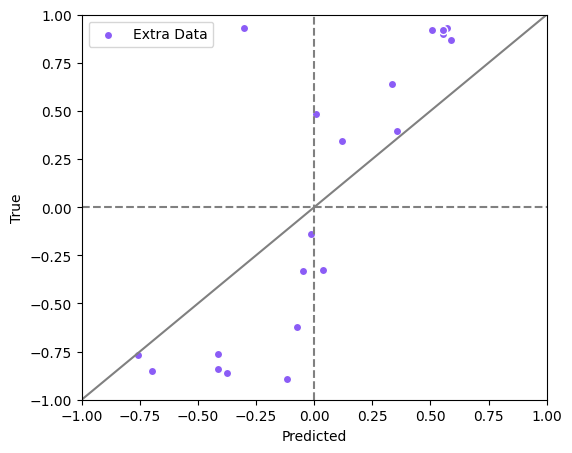

In [24]:
fig = plt.figure(figsize = (6, 5), dpi = 100)
ax = plt.gca()
ax.scatter(extra_pred, data_y_new, label = "Extra Data", c = "#8b5cf6", alpha = 1, edgecolors = "white")
ax.plot([-1, 1], [-1, 1], c = "gray")
ax.plot([0, 0], [-1, 1], c = "gray", linestyle = "--")
ax.plot([-1, 1], [0, 0], c = "gray", linestyle = "--")
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.legend()


In [25]:
data_y_new

array([-0.89  , -0.85  , -0.76  , -0.84  , -0.86  , -0.769 ,  0.93  ,
        0.93  ,  0.9   ,  0.92  ,  0.92  ,  0.87  , -0.33  , -0.6241,
       -0.327 , -0.137 ,  0.346 ,  0.483 ,  0.638 ,  0.396 ])

In [26]:
extra_pred

array([-0.11573476, -0.69932055, -0.41329545, -0.41329545, -0.37339485,
       -0.7572106 , -0.3006816 ,  0.5709511 ,  0.55613637,  0.55613637,
        0.5074378 ,  0.58882326, -0.0478259 , -0.07333592,  0.03797062,
       -0.01183841,  0.12037335,  0.00870849,  0.3361473 ,  0.35439128],
      dtype=float32)